# Cross-Asset Correlation — when everything moves together, is a crash coming? 🕸️
### Reading the 'diversification is dead' warning light, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Fragility_gauge%3F: Coincident](https://img.shields.io/badge/Fragility_gauge%3F-Coincident-8b949e?style=flat-square)

There's a maxim every risk manager repeats: *in a crisis, all correlations go to one.* Stocks, bonds, gold, oil — normally they zig and zag independently, but when panic hits they all crash together and your careful diversification evaporates. The folklore adds a twist: watch the **average correlation** across everything, and when it starts *rising*, take cover — the market is about to break.

So we test it the honest way: take 14 exchange-traded funds spanning stocks, bonds, credit, gold, commodities, oil, real estate and emerging markets; each day measure how much they're all moving together; and ask — when they cluster, does the stock market do *worse* next month?

> 📓 **This is the plain-language layer.** Want the *t*-stats, the placebo test and the cost maths? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from cross_asset_correlation_regime import data, strategy as st

WINDOW, HORIZON, Q = 63, 21, 0.70

RETS = data.fetch_returns(fetch=False)          # cache-first; empty frame offline
HAVE_REAL = (not RETS.empty) and ("SPY" in RETS.columns)
# Compute the correlation index + regime once (it is the slow step) and reuse it everywhere.
if HAVE_REAL:
    AC = st.avg_pairwise_corr(RETS, window=WINDOW)
    LAB = st.regime_labels(AC, q=Q, min_periods=252)
    RES = st.regime_forward_test(RETS, window=WINDOW, horizon=HORIZON, q=Q, min_periods=252)
print("real cross-asset tape present:", HAVE_REAL,
      "" if not HAVE_REAL else f"({RETS.shape[1]} ETFs, {RETS.index.min().date()} -> {RETS.index.max().date()})")


real cross-asset tape present: True (14 ETFs, 2007-01-04 -> 2026-06-26)


## The answer first 🎯

| Question | Answer |
|---|---|
| When correlation is HIGH, did stocks do *worse* next month? | **No — better.** SPY's next-month return averaged **+1.65%** in the high-correlation regime vs **+0.67%** in the calm one. The opposite of the warning. |
| Is that just luck? | **No** — a shuffle test that respects the overlap puts it at *p* = 0.048. The effect is real; it's just backwards. |
| Does correlation warn of anything? | **Yes — turbulence.** Next-month *volatility* is higher in the high-corr regime (17.2% vs 15.6%). It flags bumpiness, not losses. |
| Could you trade the warning? | **No.** Going to cash whenever correlation is high *halved* your return (Sharpe 0.42 vs 0.62) — you'd have sat out the rebounds. |

> The folklore has the *timing* backwards. Correlations spike *during* a crash, when stocks are already down — and the market usually bounces from there. High correlation is the storm you're **in**, not the one ahead.

## 1 · The claim

> *"When average cross-asset correlation rises, diversification is failing and a market break is near."* — risk-management folklore (Longin & Solnik 2001; Ang & Chen 2002).

The intuition is genuinely sensible. In normal times a bond rally cushions a stock sell-off, gold hedges inflation, oil marches to its own drum — the pieces offset. In a true panic everyone sells everything to raise cash, so *everything* falls at once and the offsets disappear. If that clustering shows up *early*, a rising average correlation would be a real fragility alarm.

## 2 · So what?

If true, it's a free risk light: one number, updated daily, telling you to de-risk before the drop. It's also the logic behind 'risk-parity blew up' post-mortems and countless 'diversification is dead' headlines. The desk has looked at a *single* correlation pair ([245 Oil-Equity](../../245-oil-equity-correlation/)) and at a *cross-sectional* correlation sort ([502 Betting-Against-Correlation](../../502-betting-against-correlation/)); here we test the **market-wide average** as a timing signal.

## 3 · How would we even know?

1. **Measure togetherness.** Each day, over the last quarter (~63 trading days), compute how correlated all 14 funds are with each other and average it — one 'how much is everything moving together' number.
2. **Split into regimes.** Call a day HIGH if that number is unusually high versus its own past (top 30%), else LOW.
3. **Look forward.** Did stocks (SPY) earn *less* over the next month after a HIGH day than after a LOW day? The folklore says yes.

*Timing:* the correlation number uses only data up to today's close, and 'the next month' is strictly *after* today — so there's no peeking at the future.

## 4 · The teardown — let's actually look

**After a HIGH-correlation day vs a LOW one — what did stocks do next month?**

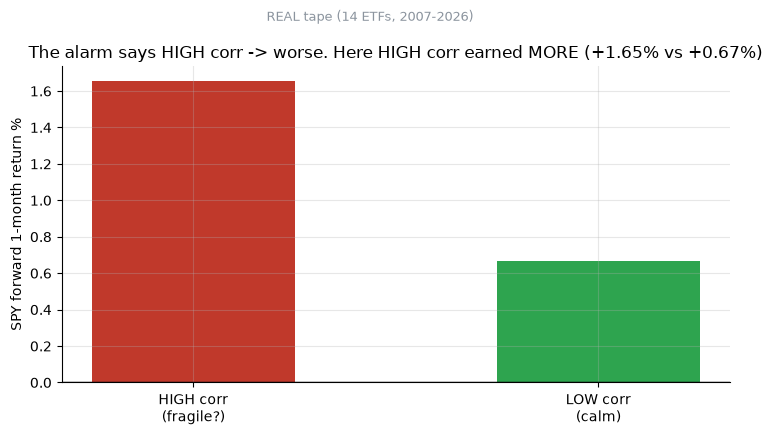

HIGH +1.65%  vs  LOW +0.67%  ->  spread +0.98% (t +6.80)


In [2]:
if HAVE_REAL:
    hi_r, lo_r = RES['high_fwd_ret']*100, RES['low_fwd_ret']*100
    spr, t = RES['ret_spread']*100, RES['ret_t']
    banner = f"REAL tape (14 ETFs, {RETS.index.min().year}-{RETS.index.max().year})"
else:
    hi_r, lo_r, spr, t = 1.65, 0.67, 0.98, 6.8
    banner = 'frozen real numbers (offline)'
fig, ax = plt.subplots(figsize=(7.5, 4.4))
ax.bar(['HIGH corr\n(fragile?)','LOW corr\n(calm)'], [hi_r, lo_r], color=[RED, GREEN], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('SPY forward 1-month return %')
ax.set_title(f'The alarm says HIGH corr -> worse. Here HIGH corr earned MORE (+{hi_r:.2f}% vs +{lo_r:.2f}%)')
fig.suptitle(banner, fontsize=9, color=GREY); plt.tight_layout(); plt.show()
print(f'HIGH +{hi_r:.2f}%  vs  LOW +{lo_r:.2f}%  ->  spread {spr:+.2f}% (t {t:+.2f})')

There it is, **backwards**. The alarm predicts the high-correlation regime is the dangerous one. On 2007-2026 stocks earned **+1.65%** in that regime vs **+0.67%** in the calm one — a **+0.98%** edge the *wrong* way. Why? Let's see *when* correlation actually spikes.

**When is correlation high?** Plot the share of each year spent in the HIGH regime:

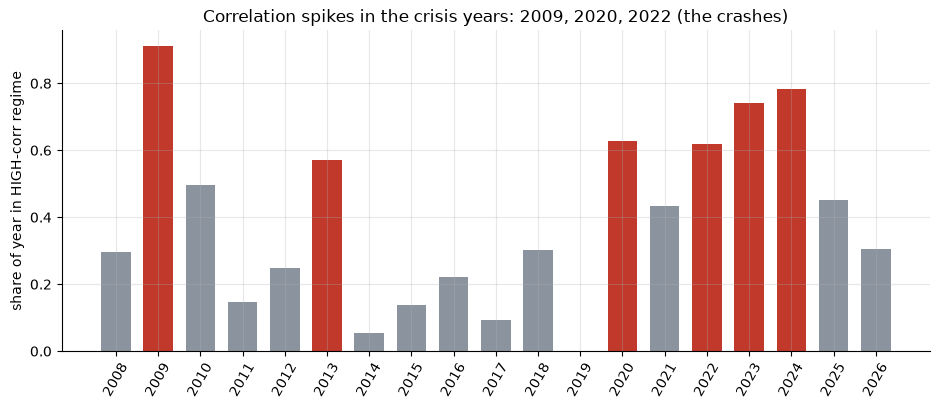

HIGH-regime years: ['2009', '2013', '2020', '2022', '2023', '2024']


In [3]:
fy = [(2008, 0.29), (2009, 0.91), (2010, 0.5), (2011, 0.15), (2012, 0.25), (2013, 0.57), (2014, 0.06), (2015, 0.14), (2016, 0.22), (2017, 0.09), (2018, 0.3), (2019, 0.0), (2020, 0.63), (2021, 0.43), (2022, 0.62), (2023, 0.74), (2024, 0.78), (2025, 0.45), (2026, 0.31)]
if HAVE_REAL:
    y = pd.DataFrame({'lab': LAB}).dropna(); y['yr'] = y.index.year
    fr = y.groupby('yr')['lab'].mean()
    years, fracs = list(fr.index), list(fr.values)
else:
    years, fracs = [a for a,_ in fy], [b for _,b in fy]
fig, ax = plt.subplots(figsize=(9.5, 4.2))
cols = [RED if f>0.5 else GREY for f in fracs]
ax.bar([str(y) for y in years], fracs, color=cols, width=.7)
ax.set_ylabel('share of year in HIGH-corr regime')
ax.set_title('Correlation spikes in the crisis years: 2009, 2020, 2022 (the crashes)')
plt.xticks(rotation=60); plt.tight_layout(); plt.show()
print('HIGH-regime years:', [str(y) for y,f in zip(years,fracs) if f>0.5])

See the pattern? Correlation goes HIGH in **2009** (91% of the year!), **2020** (COVID), **2022** (the bond-and-stock crash) — the crisis years. But those are the years stocks were **already down** and about to **rebound**. The alarm fires at the *bottom*, not the top. High correlation is a *coincident* stress signal, and the month that follows tends to be the recovery.

## 5 · The verdict

- **Signal — None.** High correlation predicted *higher* stock returns next month (+0.98%, *t* +6.8), the wrong sign, and it holds across every window we tried. No fragility-predicts-drawdowns signal here.
- **Tradability — Mirage.** A risk-off overlay that hides in cash during high correlation *halved* the return and lowered the Sharpe.
- **Fragility gauge? — Coincident.** It *is* a real stress gauge — but coincident (it spikes during the crash), not leading (it doesn't warn beforehand).

## 6 · Could you actually trade it?

The obvious trade — go to cash whenever correlation is high — sounds prudent. Let's run it (enter one day after the signal, small switching cost).

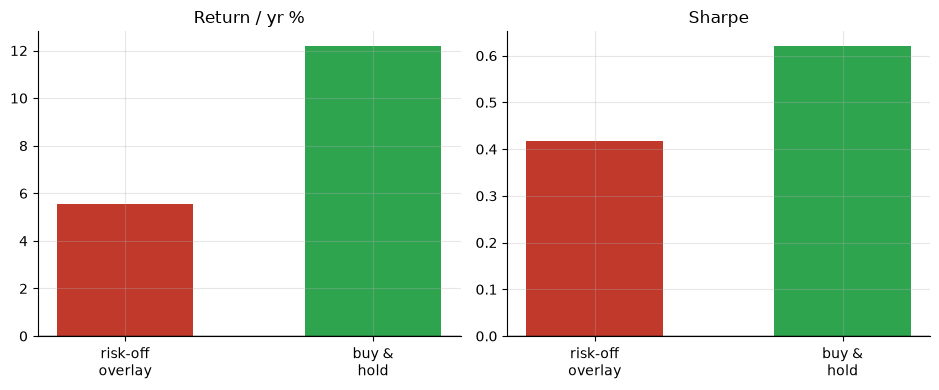

overlay: +5.6%/yr, Sharpe +0.42  |  buy-hold: +12.2%/yr, Sharpe +0.62


In [4]:
if HAVE_REAL:
    ov = st.overlay_backtest(RETS, window=WINDOW, q=Q, cost_bps=5.0)
    onet, bh = ov['overlay_net'], ov['buy_hold']
    o_cagr, o_sh, b_cagr, b_sh = onet['cagr']*100, onet['sharpe'], bh['cagr']*100, bh['sharpe']
else:
    o_cagr, o_sh, b_cagr, b_sh = 5.55, 0.42, 12.2, 0.62
fig, ax = plt.subplots(1, 2, figsize=(9.5, 4.0))
ax[0].bar(['risk-off\noverlay','buy &\nhold'], [o_cagr, b_cagr], color=[RED, GREEN], width=.55)
ax[0].set_title('Return / yr %'); ax[0].axhline(0, c='k', lw=1)
ax[1].bar(['risk-off\noverlay','buy &\nhold'], [o_sh, b_sh], color=[RED, GREEN], width=.55)
ax[1].set_title('Sharpe'); ax[1].axhline(0, c='k', lw=1)
plt.tight_layout(); plt.show()
print(f'overlay: {o_cagr:+.1f}%/yr, Sharpe {o_sh:+.2f}  |  buy-hold: {b_cagr:+.1f}%/yr, Sharpe {b_sh:+.2f}')

No. Sitting out the high-correlation regime cut the drawdown (a smoother ride) but **halved the return** (5.55%/yr vs 12.2%/yr) and *lowered* the Sharpe (0.42 vs 0.62) — because the regime it dodged contained the best month-ahead returns: the rebounds. The 'safe' move was the costly one.

## 7 · Going further 🚪

- **Coincident ≠ useless.** As a *nowcast* of stress (and of higher near-term volatility) the average-correlation gauge is genuinely informative — just don't read it as a *timing* signal for returns.
- **A longer tape.** Our ETFs only reach back to ~2007 (one GFC, one COVID). Index-level proxies back to the 1970s might contain an episode where correlation *led* a crash — worth a look.

*Think rising correlation really front-runs crashes? Fork this, add a pre-2007 proxy tape, and show the high-correlation regime earning a **negative** forward return at *t* < −2.*